# Diabetes Prediction - KNN vs Logistic Regression

In this project I used the Pima Indians Diabetes dataset to predict whether a patient has diabetes or not.
I compared two classification models, KNN and Logistic Regression, and evaluated them using accuracy, confusion matrix and classification report.

## Imports

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load the Dataset

In [19]:
df = pd.read_csv('diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
# checking for null values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 2. Exploratory Data Analysis

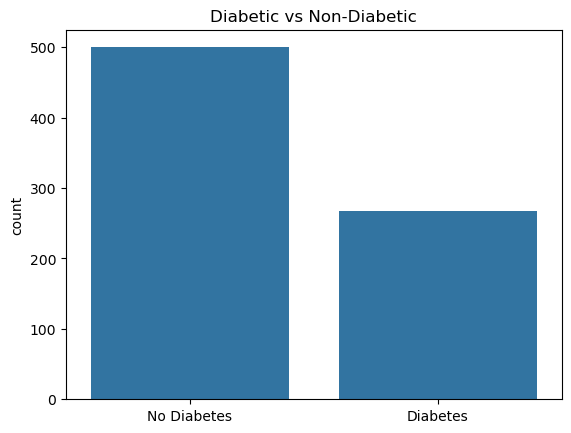

In [22]:
# how many patients have diabetes vs not
sns.countplot(x='Outcome', data=df)
plt.title('Diabetic vs Non-Diabetic')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.xlabel('')
plt.show()

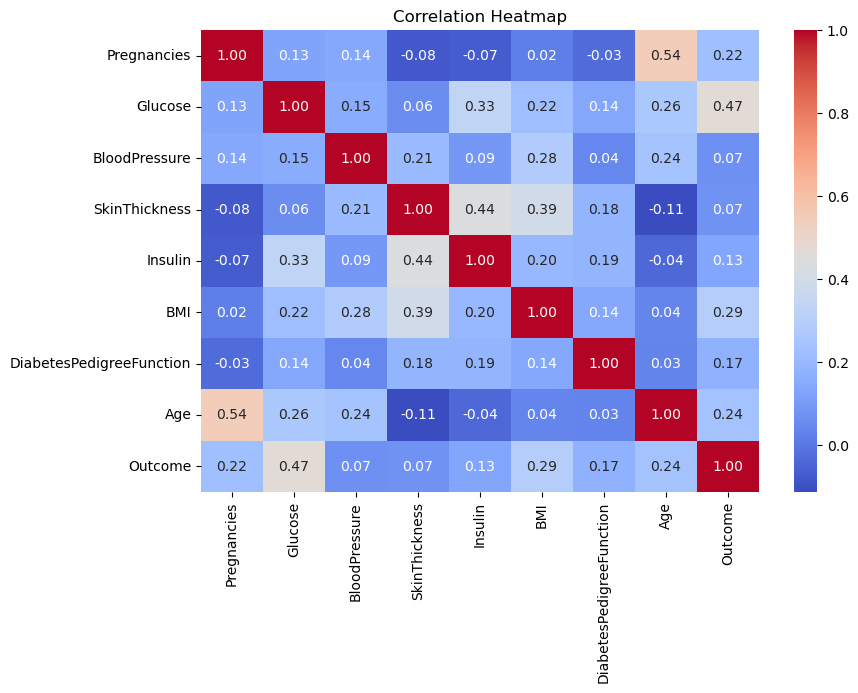

In [23]:
# correlation between features
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

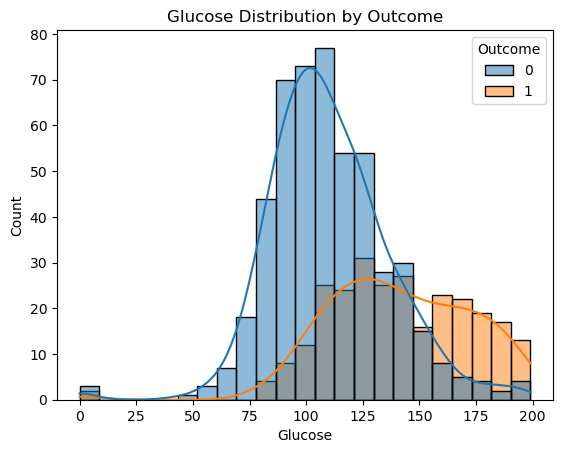

In [24]:
# glucose seems like an important feature, lets see its distribution
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title('Glucose Distribution by Outcome')
plt.show()

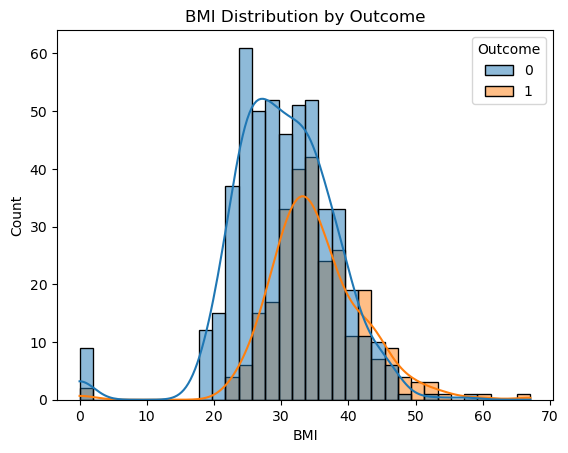

In [25]:
# bmi distribution by outcome
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True)
plt.title('BMI Distribution by Outcome')
plt.show()

## 3. Preprocessing

Some columns like Glucose, BMI and BloodPressure have 0 values which dont make sense biologically. I replaced them with the median of each column.

In [26]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())

print('done replacing zeros with median')

done replacing zeros with median


In [27]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling is important especially for KNN since it uses distance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('train size:', X_train.shape[0])
print('test size: ', X_test.shape[0])

train size: 614
test size:  154


## 4. Training the Models

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [29]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

## 5. Evaluation and Comparison

In [30]:
knn_acc = accuracy_score(y_test, knn.predict(X_test))
lr_acc  = accuracy_score(y_test, lr.predict(X_test))

print(f'KNN accuracy:                 {knn_acc:.4f}')
print(f'Logistic Regression accuracy: {lr_acc:.4f}')

KNN accuracy:                 0.7532
Logistic Regression accuracy: 0.7662


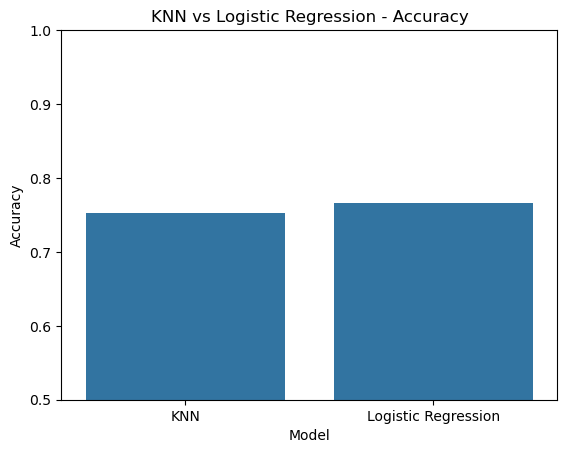

In [31]:
# bar chart comparing both models
results = pd.DataFrame({
    'Model':    ['KNN', 'Logistic Regression'],
    'Accuracy': [knn_acc, lr_acc]
})

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('KNN vs Logistic Regression - Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

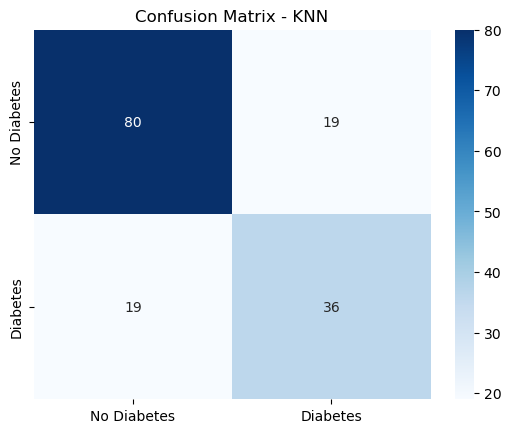

In [32]:
# confusion matrix for KNN
cm_knn = confusion_matrix(y_test, knn.predict(X_test))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - KNN')
plt.show()

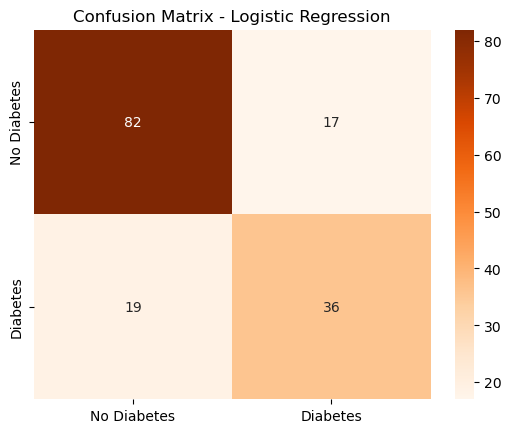

In [33]:
# confusion matrix for logistic regression
cm_lr = confusion_matrix(y_test, lr.predict(X_test))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [34]:
print('KNN:')
print(classification_report(y_test, knn.predict(X_test)))

print('Logistic Regression:')
print(classification_report(y_test, lr.predict(X_test)))

KNN:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Logistic Regression:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



## Conclusion

Logistic Regression performed slightly better than KNN on this dataset. This makes sense because the data is mostly linearly separable and logistic regression handles that well. KNN is more sensitive to the scale of features and the choice of K which can affect its performance.

The most important feature based on the correlation heatmap was Glucose, followed by BMI and Age.